# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,1.170315e+07,1169.454063,0.938520,0.533666,0.015465,0.0,8.73,0.47,8.26,6.525901,1.793124,0.004575,0.015051,3.349148,1.170655,0.000340,0.000117
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,1.170440e+07,704.233287,0.733999,0.591022,0.008749,0.0,8.72,0.53,8.19,6.526075,1.793266,0.002971,0.015048,3.349148,1.170655,0.000215,0.000070
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.170486e+07,404.852333,0.563481,0.456359,0.004241,0.0,8.71,0.30,8.41,6.526193,1.793361,0.001677,0.015046,3.349148,1.170655,0.000169,0.000040
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,1.170576e+07,265.433740,0.403121,0.474074,0.003044,0.0,8.70,0.26,8.44,6.526227,1.793389,0.001323,0.015046,3.349148,1.170655,0.000079,0.000027
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.0,0.0,0.0,4.0,-3.0,1.5,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,1.170559e+07,301.436868,0.465383,0.364764,0.003110,0.0,8.70,0.27,8.43,6.526216,1.793380,0.001195,0.015046,3.349148,1.170655,0.000096,0.000030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73124995,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,0.0,0.0,0.0,0.0,4.0,1.118347e+07,7436.435639,0.459242,0.175508,0.005730,0.0,30.00,0.20,29.80,0.056774,0.921280,0.008362,0.519148,3.172940,1.119627,0.001279,0.000744
73124996,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,-4.0,1.110062e+07,67465.039753,1.588473,0.169109,0.086969,0.0,30.00,0.27,29.73,0.056356,0.915344,0.033034,0.517919,3.172940,1.119627,0.009565,0.006747
73124997,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,-2.0,1.115667e+07,22430.443053,1.128367,0.157228,0.015391,0.0,30.00,0.23,29.77,0.056645,0.919882,0.020199,0.519193,3.172940,1.119627,0.003959,0.002243
73124998,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,-1.5,-1.5,2.0,0.0,0.0,0.0,0.0,1.118143e+07,8560.613140,0.753660,0.181480,0.006785,0.0,30.00,0.27,29.73,0.056764,0.921176,0.008768,0.519154,3.172940,1.119627,0.001483,0.000856


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

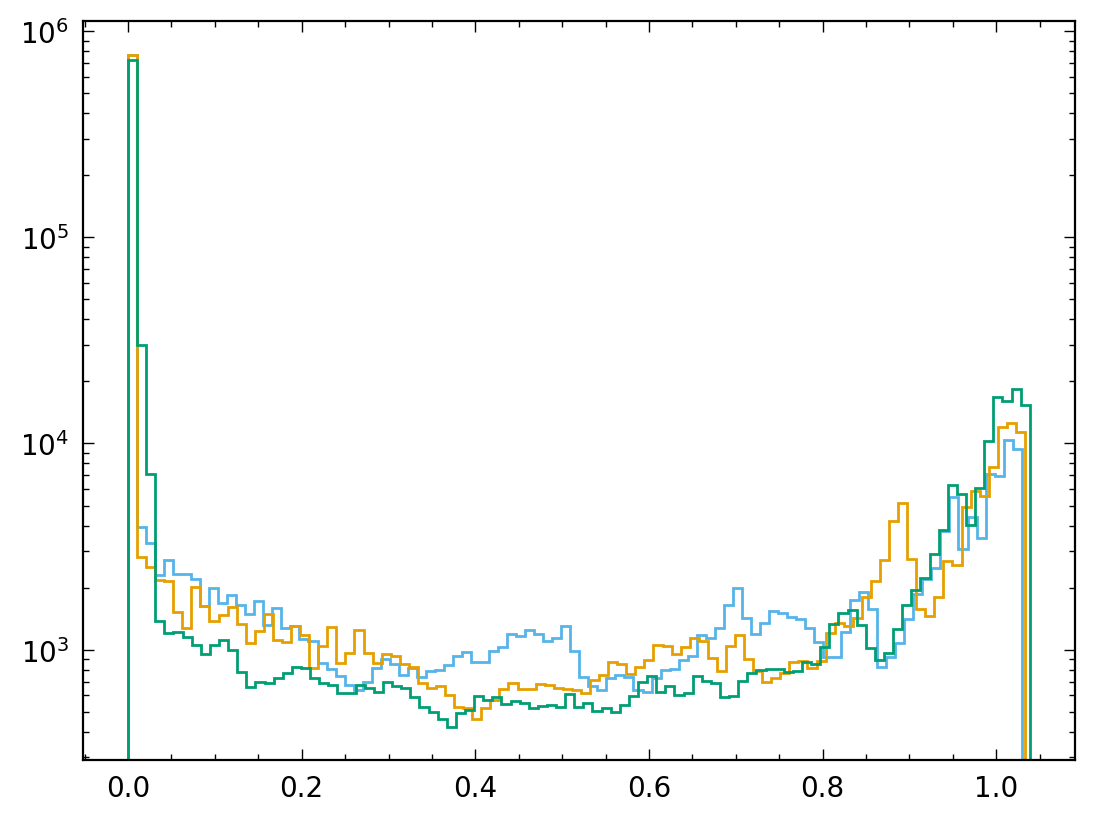

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.003307,3.480582
1,0.544286,0.001341,0.087222,3.494672
2,0.556817,0.009183,0.467280,3.491761
3,0.562162,0.000164,0.003307,3.477065
4,0.569737,0.020705,0.815850,3.480038
...,...,...,...,...
223,3.120998,6.309107,2.026758,3.473683
224,3.172940,0.056840,0.921962,3.690684
225,3.349148,6.526466,1.793639,3.498413
226,5.611731,0.460502,0.921962,3.724382


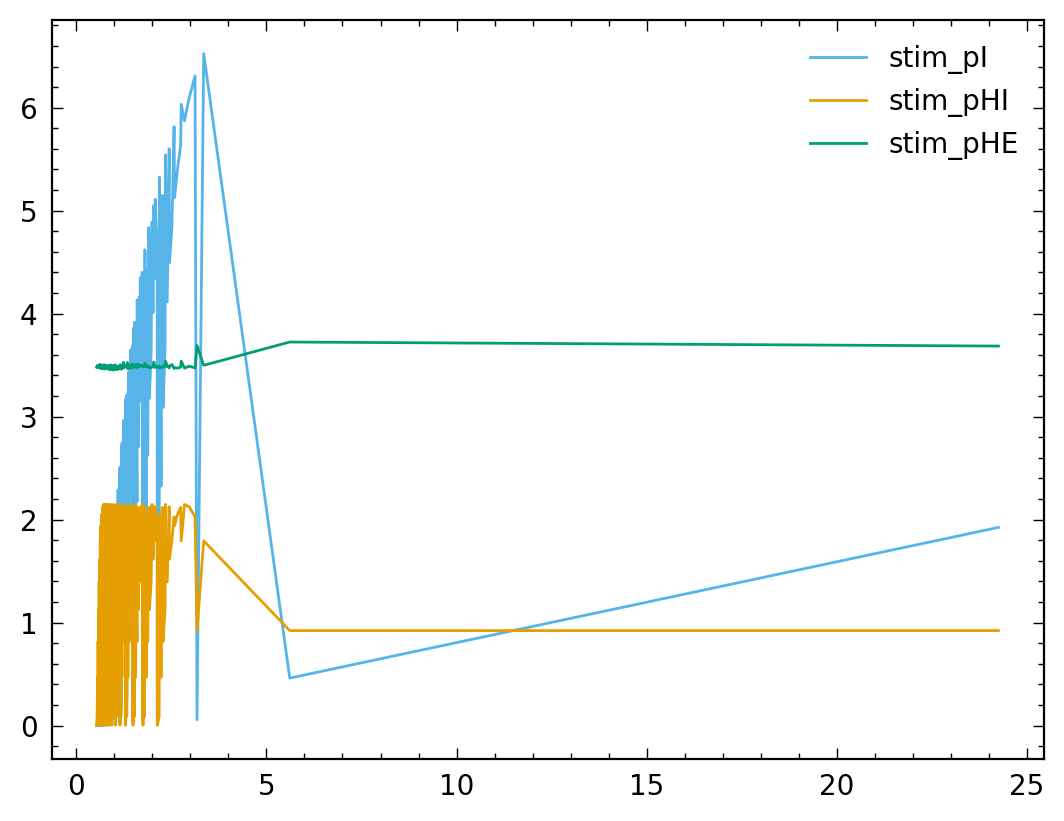

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

In [6]:
# # Explore noise in the data
# fig, axs = plt.subplots(1, len(perf_vars), 
#                               figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


# data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
# for i, var in enumerate(perf_vars):
#     im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
#                         (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
#                       marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
#                         edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

#     if module_index + j == 0: 
#         axs[i].minorticks_off()
#         axs[i].yaxis.set_tick_params(labelbottom=True)
#         axs[i].xaxis.set_tick_params(labelbottom=True)
#         axs[i].tick_params(axis='both', which='major', labelsize=8)
#         axs[i].set_box_aspect(1)
#         axs[i].locator_params(axis='y', nbins=4)
#         axs[i].locator_params(axis='x', nbins=4)
#         axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
#         axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

# axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
# fig.subplots_adjust(wspace=.4, hspace=.35)
# #plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 13
fevals: 848
fevals: 7
fevals: 12
fevals: 63
fevals: 123
fevals: 51
fevals: 15
fevals: 11
fevals: 48
fevals: 7
fevals: 8
fevals: 11
fevals: 51
fevals: 7
fevals: 8


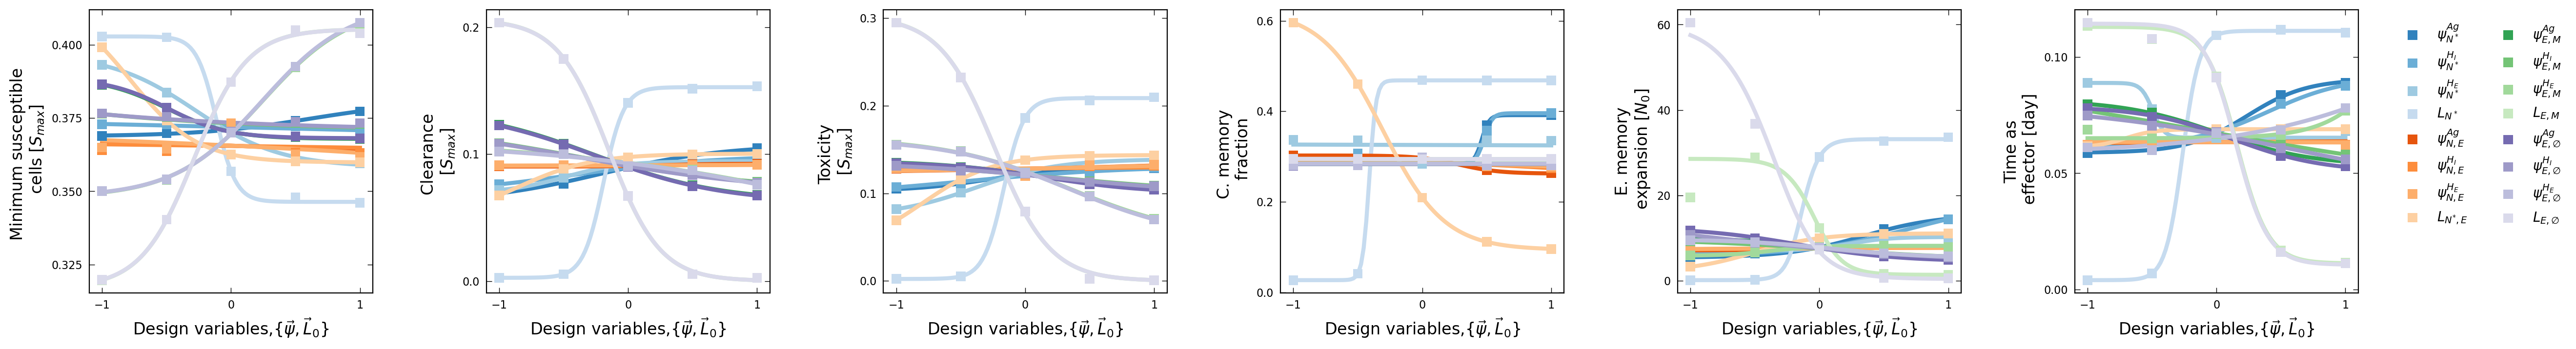

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.172886e+00,3.395913e-03,4.063099e+00,1.921751e-02,1.048902e-01,4.036023,3.560250e-01,2.439493e-02,-1.397975e-03,1.149398,-6.421232e+00,-2.775900e-01,-3.673803e-01,-3.445608,-6.154117,-0.264435,-0.338724,-3.318520,3.815283,5.614081,-1.758341,-1.741776,9.810812e-04,2.222814e-04,3.820277e-02,5.541494e-03,5.592455e-03,3.847162e-02,0.006075,0.005742,0.005740,0.018141,0.042516,0.006795,0.007137,2.404711e-02,0.039712,0.006577,0.006839,2.268097e-02,3.925204e-02,7.348697e-02,0.007323,0.007213,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.324342e-01,1.169431e+00,-5.854587e-05,2.979609e-05,1.0,1.097198e-01,3.454459e-01,0.971112,1.170655,6.526300,1.793448,3.334697,3.349148
7,1.172495e+00,3.371447e-03,3.679588e+00,5.647727e-02,1.218565e-01,3.912868,2.542269e-01,4.571878e-03,1.697200e-03,1.299303,-4.639714e+00,-2.769217e-01,-3.425779e-01,-2.789753,-4.576412,-0.279804,-0.344350,-2.776579,3.546544,6.296306,-1.598557,-1.572766,1.128696e-03,2.285601e-04,3.217883e-02,5.787800e-03,5.851934e-03,3.316426e-02,0.006360,0.006191,0.006191,0.028824,0.029283,0.005347,0.005476,1.953616e-02,0.029415,0.005292,0.005414,1.982397e-02,3.230654e-02,1.164180e-01,0.006640,0.006521,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.313292e-01,1.169065e+00,-5.854587e-05,2.189021e-05,1.0,1.124557e-01,3.429993e-01,0.949090,1.170655,6.033823,1.793448,3.347375,2.758122
13,1.172175e+00,3.343625e-03,3.255152e+00,1.072257e-01,3.750308e-01,3.921147,1.549909e-01,-3.486901e-03,6.907231e-03,1.071047,-3.826770e+00,-2.030159e-01,-3.806390e-01,-3.668849,-3.685177,-0.170138,-0.340318,-3.543981,3.155967,5.253569,-1.711542,-1.710515,1.016741e-03,2.187024e-04,2.707446e-02,6.206960e-03,6.829276e-03,3.080275e-02,0.005623,0.005554,0.005554,0.017034,0.027034,0.005297,0.005705,2.328480e-02,0.025343,0.005157,0.005513,2.190005e-02,2.593475e-02,6.895431e-02,0.007004,0.006979,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.296862e-01,1.168773e+00,-5.854587e-05,1.245733e-05,1.0,1.082580e-01,3.402171e-01,0.912025,1.170655,5.541939,1.793448,3.341870,2.344404
19,1.171628e+00,3.309509e-03,3.298685e+00,1.305382e-01,1.042082e+00,5.641680,9.856668e-02,7.406910e-03,1.257255e-03,1.131017,-3.330030e+00,-2.261127e-01,-3.686661e-01,-3.489744,-3.268014,-0.215332,-0.345252,-3.416773,3.153717,5.493312,-1.786531,-1.777204,9.639350e-04,2.040466e-04,3.183287e-02,6.935690e-03,1.128480e-02,5.036121e-02,0.005303,0.005277,0.005277,0.018246,0.017929,0.004876,0.005257,1.810453e-02,0.017431,0.004797,0.005124,1.753623e-02,2.634280e-02,7.378075e-02,0.006956,0.006896,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,1.275089e-01,1.168260e+00,-5.854587e-05,2.944170e-06,1.0,1.018793e-01,3.368055e-01,0.890578,1.170655,5.051025,1.793448,3.343688,2.038612
25,1.171078e+00,3.270062e-03,3.141089e+00,1.912243e-01,1.649221e+00,8.931282,8.778168e-02,-3.610235e-03,4.042062e-03,1.242085,-2.440966e+00,-2.640891e-01,-4.824050e-01,-2.921965,-2.425746,-0.250982,-0.496478,-2.909532,3.649015,5.972824,-1.736268,-1.740529,9.745671e-04,1.955070e-04,3.345664e-02,8.811538e-03,2.000708e-02,9.488740e-02,0.005215,0.005194,0.005194,0.022518,0.012153,0.004272,0.004749,1.399739e-02,0.012053,0.004242,0.004773,1.388694e-02,3.995968e-02,9.09

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

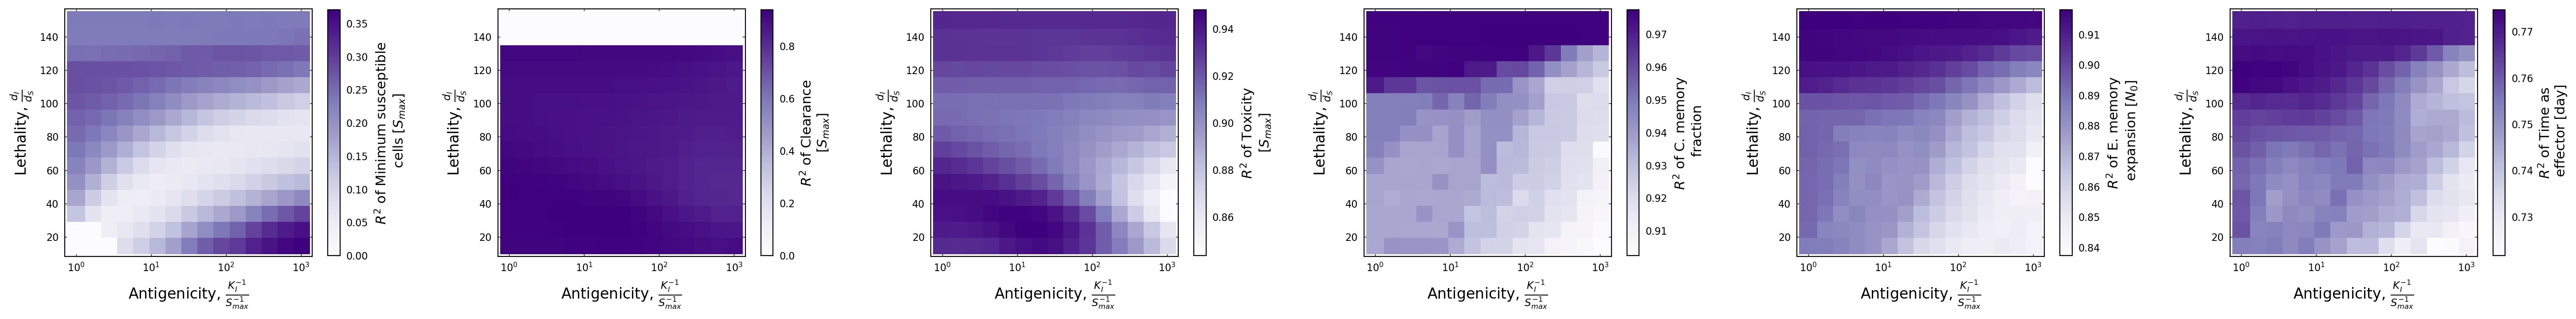

In [12]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

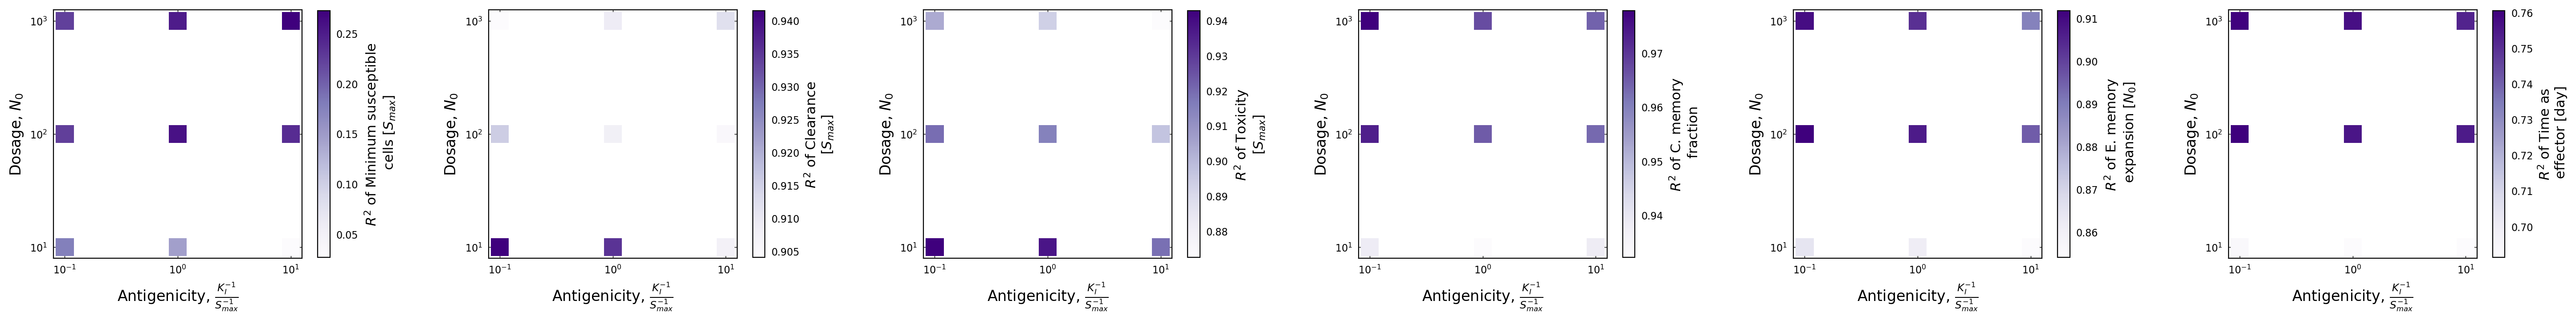

In [13]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

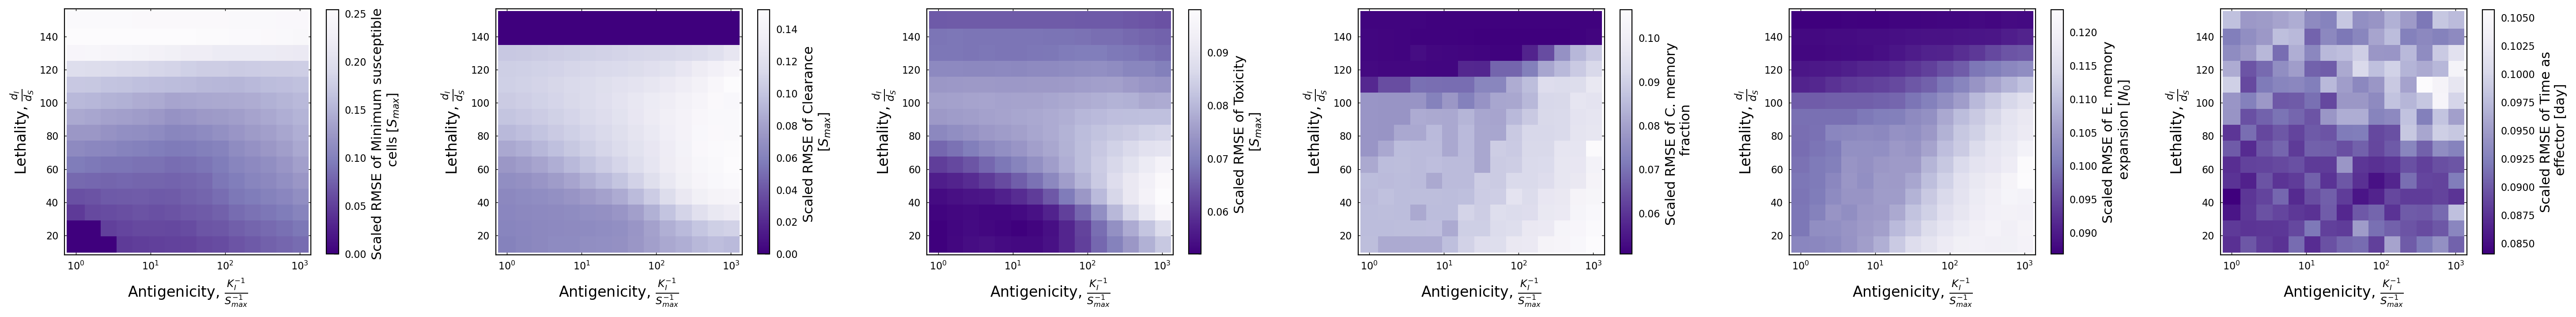

In [14]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

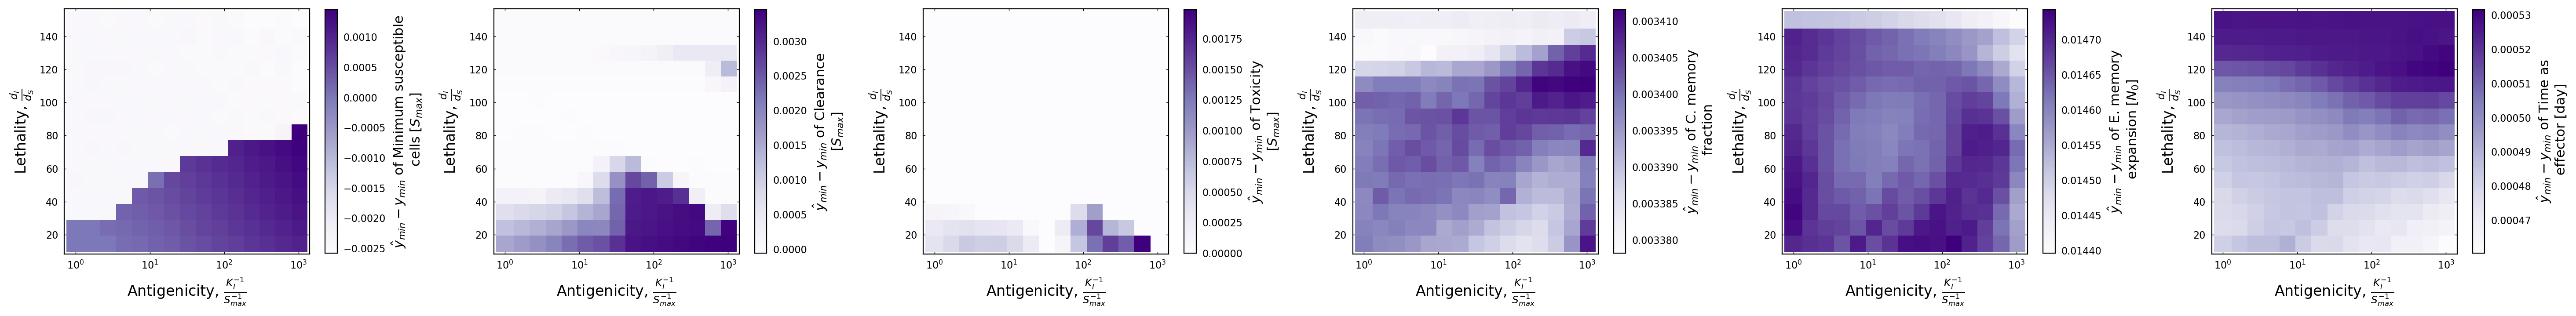

In [15]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

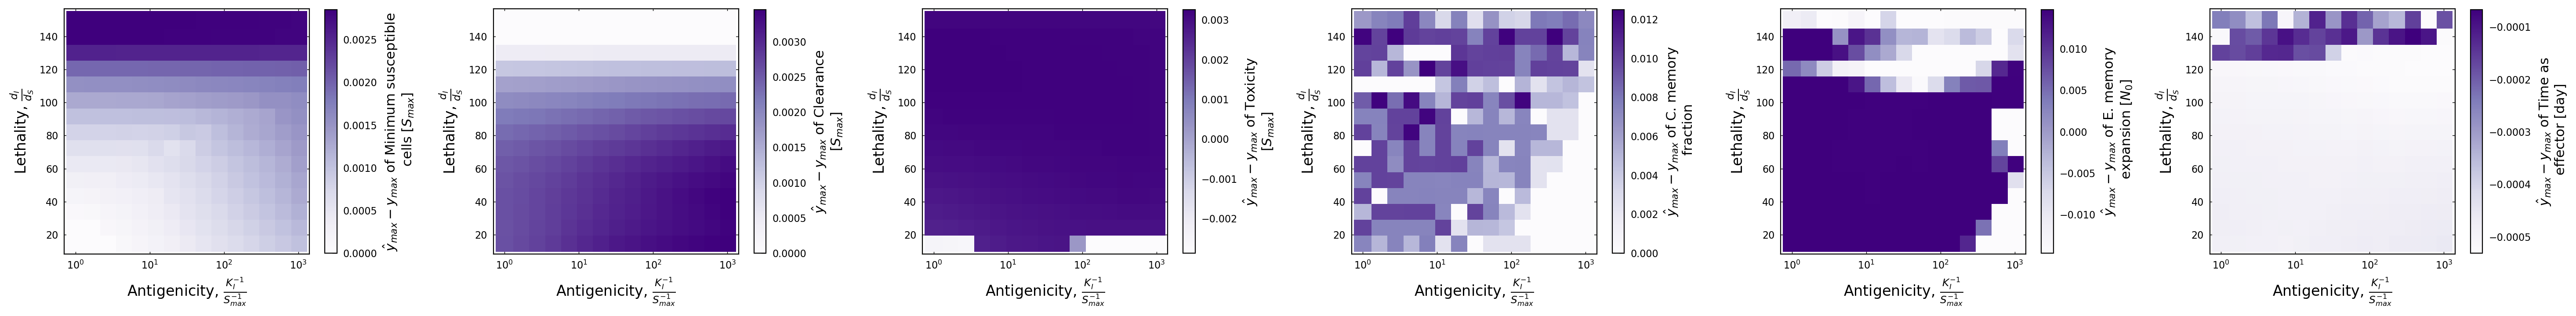

In [16]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

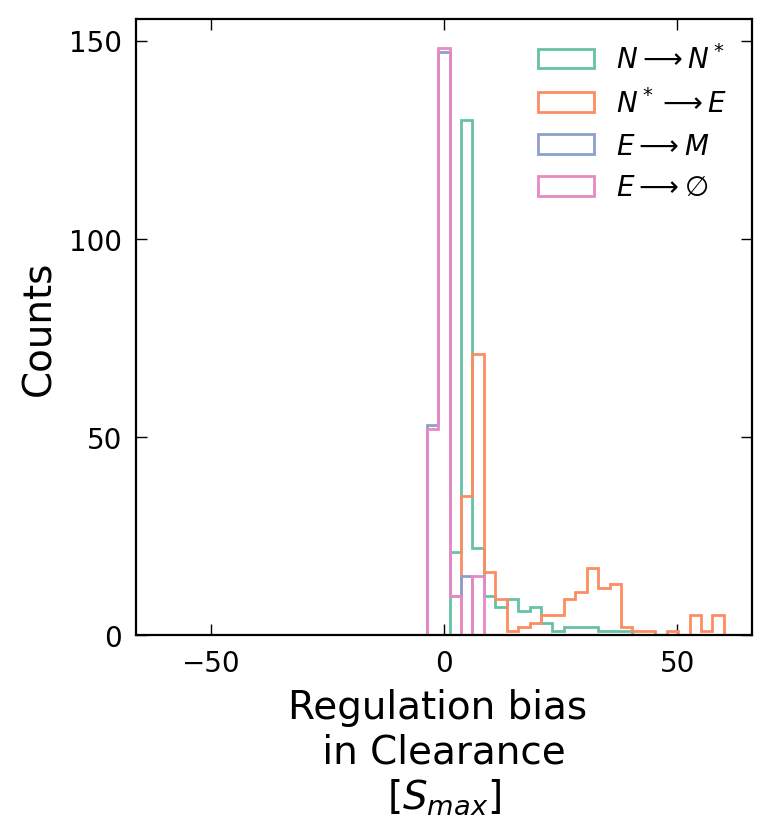

In [17]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

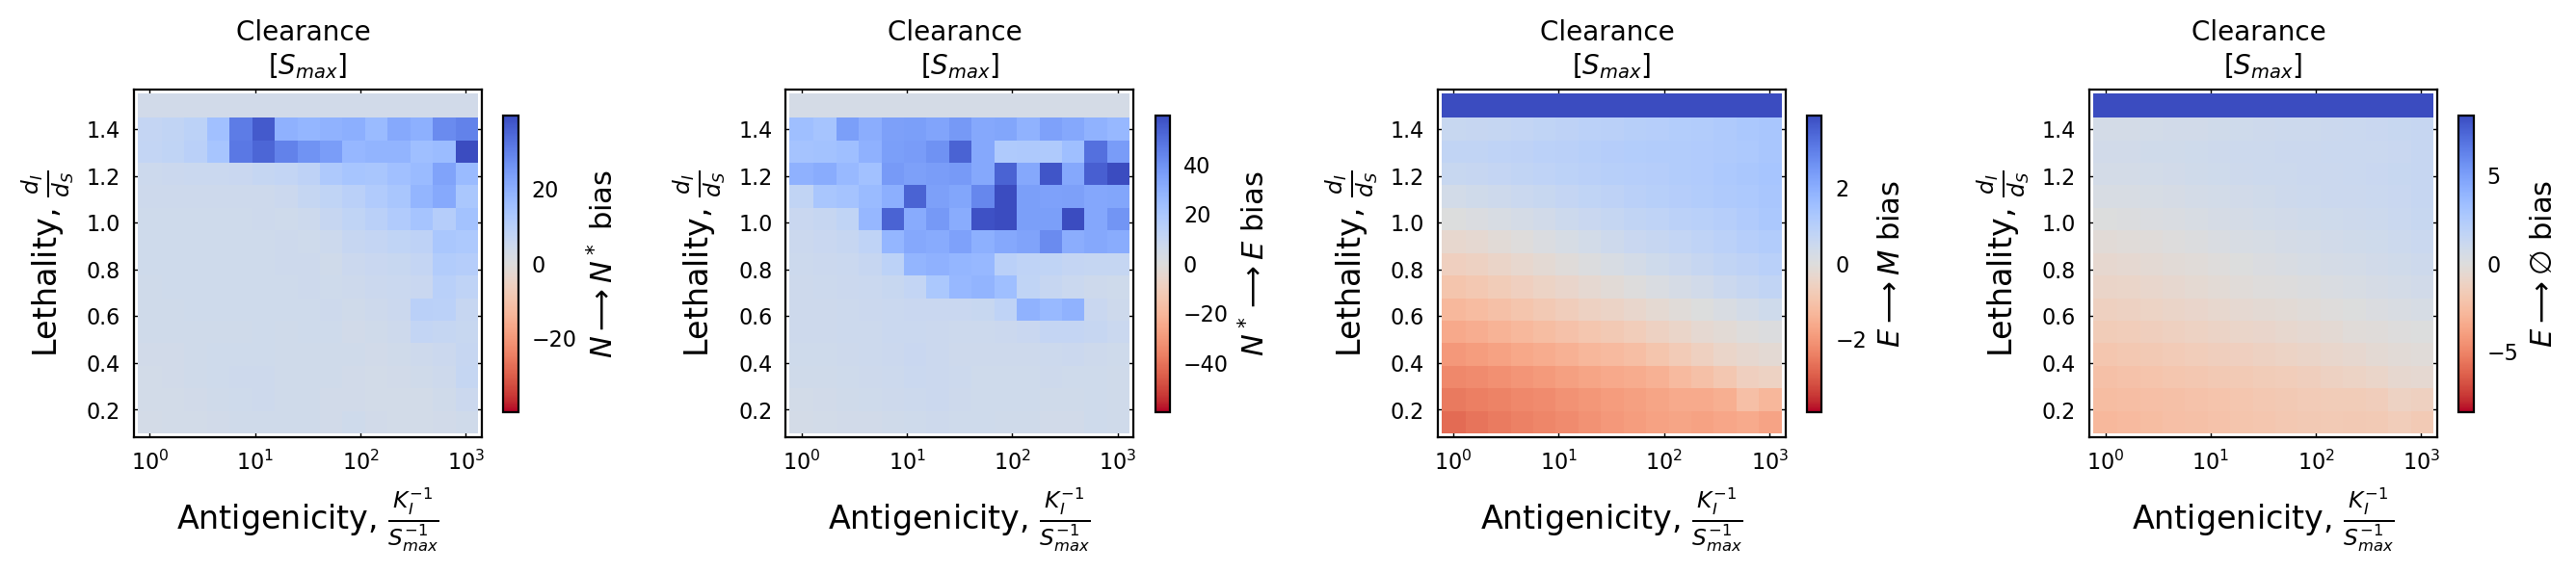

In [18]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

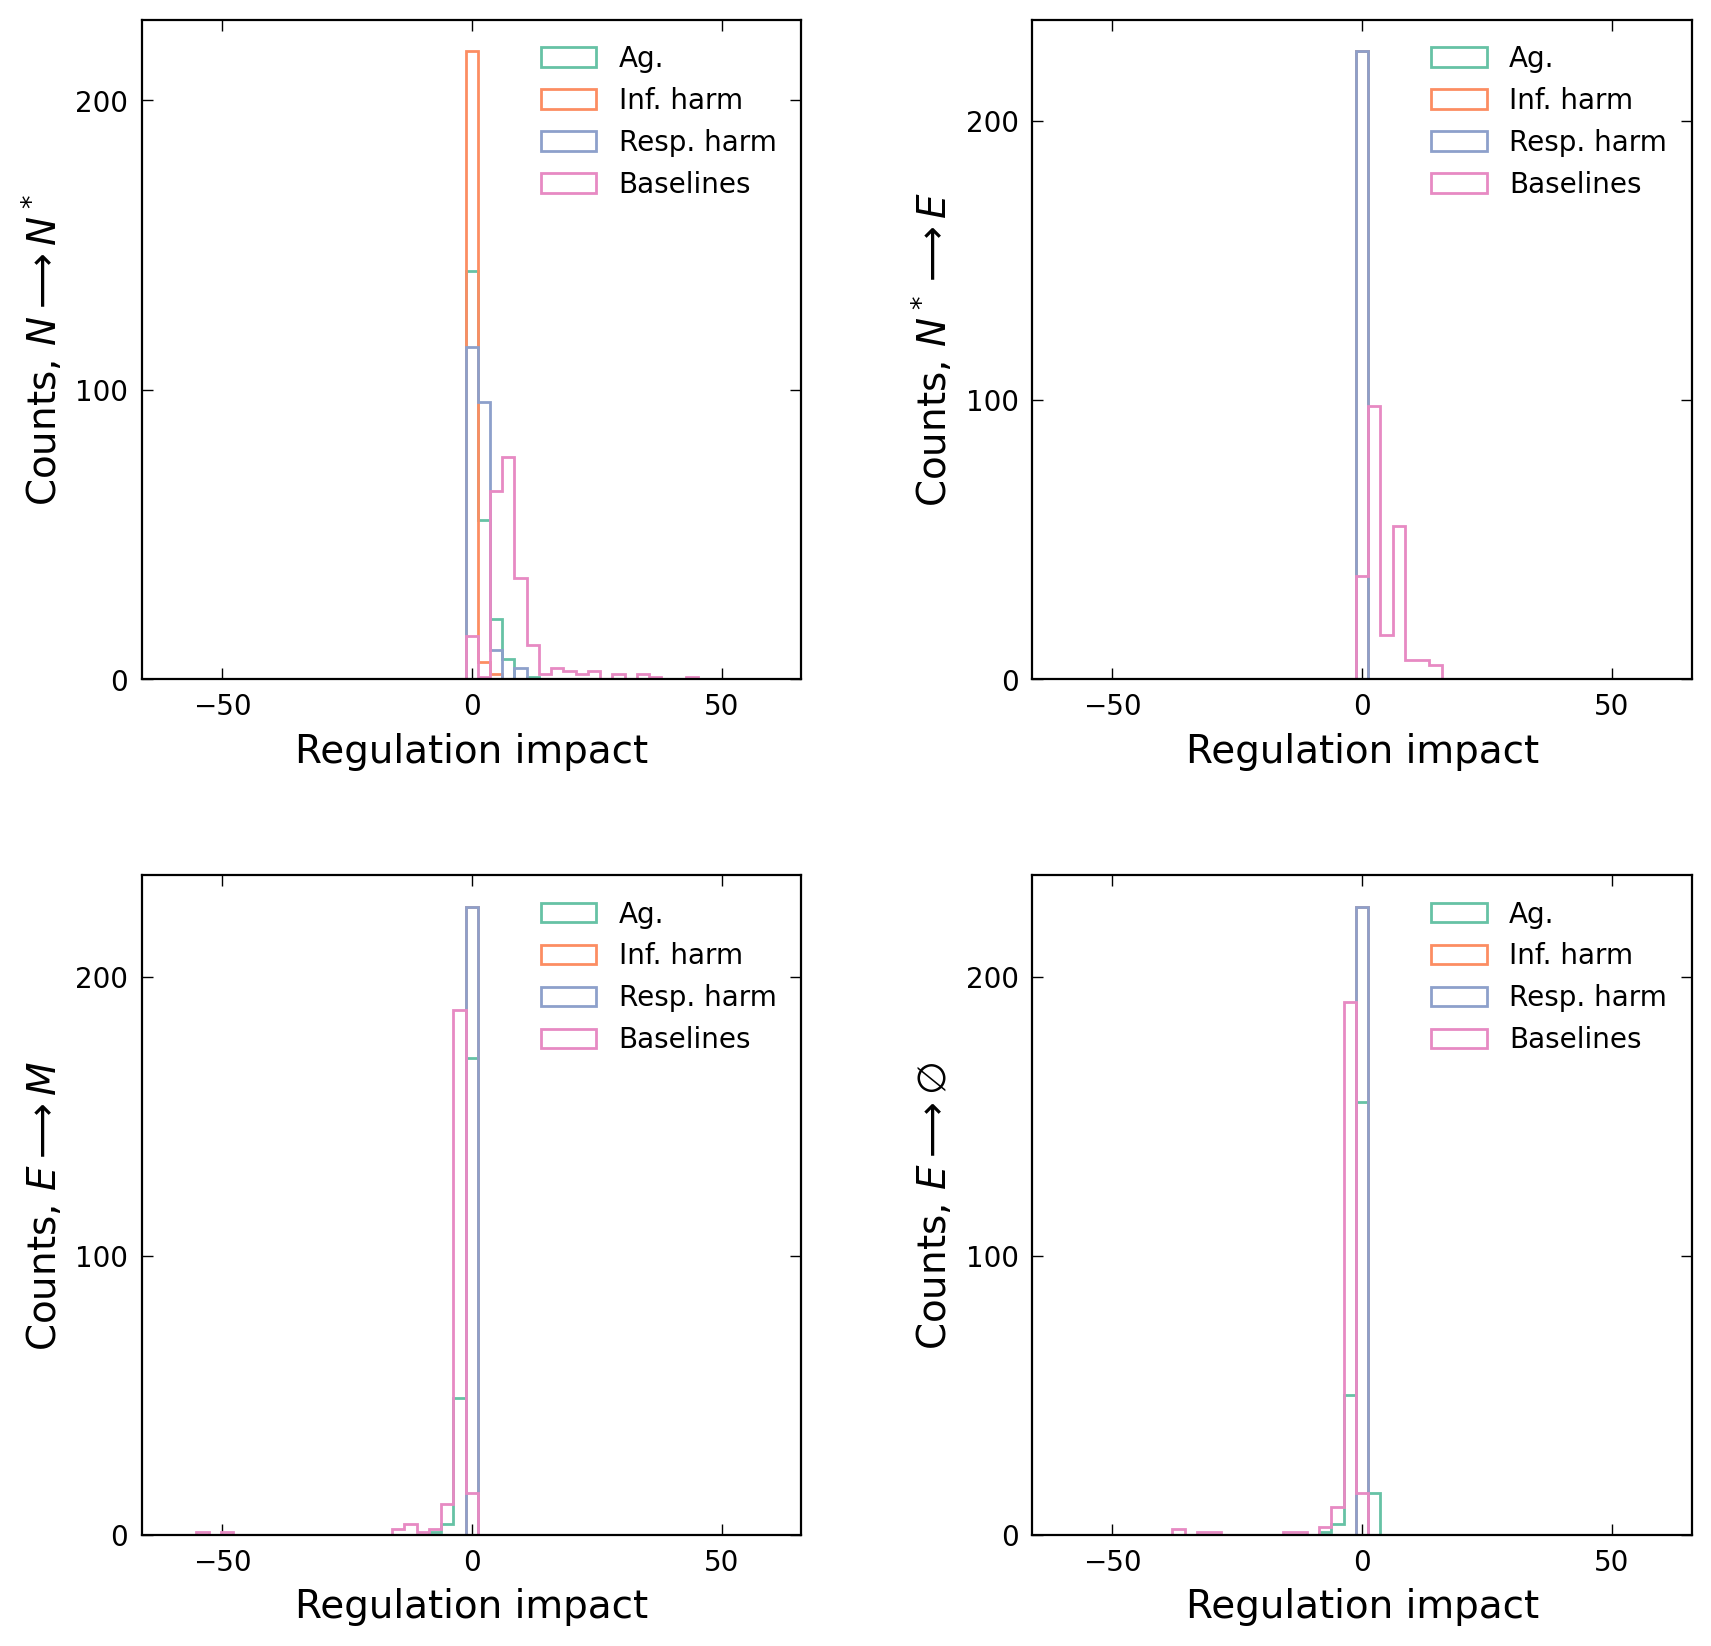

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1351,1.024013,-0.000112,3.808410,1.859157,0.973991,5.081810,0.546937,0.276286,0.024832,1.228264,-1.265761,-0.683691,-0.443071,-2.006109,-1.271872,-0.688285,-0.453155,-2.022710,3.591638,4.872206,-0.769156,-0.764654,0.000977,0.000177,0.036659,0.018760,0.011396,0.048225,0.005454,0.004746,0.004458,0.007889,0.007374,0.004971,0.004217,0.010254,0.007478,0.005030,0.004276,0.010464,0.034847,0.031187,0.003927,0.003926,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.110120,1.021172,-0.000112,-0.000099,1.0,0.086402,0.284038,0.806419,1.119627,1.924058,0.921962,2.410491,24.253500
1357,1.033256,-0.000112,3.732572,1.833114,0.982409,5.000314,0.405127,0.216817,0.013058,1.362975,-1.728077,-0.898708,-0.461731,-2.547426,-1.747757,-0.915007,-0.469165,-2.573667,3.577567,7.086592,0.370684,0.376881,0.000843,0.000224,0.035350,0.018224,0.011272,0.046655,0.007163,0.006965,0.006800,0.039218,0.013423,0.007884,0.005527,0.018693,0.013654,0.008044,0.005599,0.019017,0.034124,0.158621,0.004038,0.004046,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.158398,1.029776,-0.000112,0.000091,1.0,0.107075,0.347981,0.809564,1.119627,1.924058,0.921962,3.385183,24.253500
1363,1.042219,-0.000112,3.519606,1.615577,0.993083,4.860200,0.342242,0.184348,-0.005007,7.138658,-1.524553,-0.801159,-0.532869,-2.345565,-1.529433,-0.805756,-0.536269,-2.356239,3.691100,31.655733,0.819091,0.821027,0.000817,0.000238,0.032439,0.015897,0.010952,0.044048,0.018560,0.018023,0.016778,17493.395612,0.009349,0.005953,0.004971,0.013023,0.009413,0.005993,0.004998,0.013142,0.034229,69973.617683,0.004561,0.004565,0.01,1000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.181969,1.038485,-0.000112,0.001937,1.0,0.110744,0.373408,0.812171,1.119627,1.924058,0.921962,3.662783,24.253500
1369,1.005351,-0.000112,0.725044,2.800837,1.360349,6.230798,0.075315,0.246265,0.018179,1.135133,-0.124599,-0.519836,-0.737321,-1.534097,-0.128131,-0.520956,-0.741601,-1.535001,3.592152,3.948265,-1.661899,-1.668335,0.000908,0.000112,0.008869,0.024059,0.013209,0.051523,0.003122,0.003219,0.003112,0.004201,0.002342,0.002613,0.002876,0.003443,0.002342,0.002613,0.002881,0.003443,0.030355,0.015729,0.004410,0.004426,0.01,10000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.074755,1.003176,-0.000112,-0.000108,1.0,0.055297,0.217523,0.579925,1.119627,0.460502,0.921962,2.511152,5.611731
1375,1.026465,-0.000112,0.793325,2.773669,1.606745,6.179182,0.050751,0.188550,0.030342,1.063617,-0.206638,-0.809839,-0.529207,-2.083422,-0.208236,-0.807983,-0.524456,-2.076852,3.463096,5.268675,-0.083828,-0.084592,0.000937,0.000202,0.010523,0.027223,0.017231,0.058319,0.005229,0.005317,0.005224,0.016120,0.003929,0.006384,0.005151,0.013352,0.003927,0.006358,0.005117,0.013260,0.032791,0.065302,0.003642,0.003641,0.01,10000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.136266,1.023299,-0.000112,-0.000050,1.0,0.096119,0.316635,0.573662,1.119627,0.460502,0.921962,3.440651,5.611731
1381,1.036510,-0.000112,0.776448,2.326206,1.551763,5.589563,0.042863,0.171722,0.005106,1.764920,-0.289358,-0.965792,-0.748774,-2.538120,-0.295454,-0.980536,-0.748622,-2.555774,3.348003,9.446720,0.521490,0.523779,0.000846,0.000224,0.009522,0.021331,0.015387,0.048477,0.012751,0.012734,0.012736,0.237776,0.004542,0.007801,0.006735,0.017496,0.004581,0.00